# Graph Neural Networks — Simple Implementation

**One idea per cell. Every concept explained before the code.**

---

## Road Map
| Cell | What we do |
|---|---|
| 1 | Imports |
| 2 | Load the Karate Club graph |
| 3 | Draw the graph |
| 4 | Message passing by hand |
| 5 | Build a GCN and train it |
| 6 | Build a GAT and train it |
| 7 | Prove over-smoothing is real |
| 8 | Fix it with Jumping Knowledge |
| 9 | See what the model learned (t-SNE) |

---
## Cell 1 — Imports

We only need four libraries:
- **torch** — the deep learning engine
- **torch_geometric** — graph-specific layers (GCNConv, GATConv)
- **networkx + matplotlib** — to draw the graph
- **sklearn** — for t-SNE (shrinking embeddings to 2D for visualisation)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv, GATConv

import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print('All imports OK')

All imports OK


---
## Cell 2 — Load the Karate Club Graph

The **Karate Club** is a classic dataset — 34 members of a karate club.
An edge connects two members if they interacted outside the club.
The club split into **4 groups** — that is our classification task.

PyG stores a graph in a `data` object with 3 things:
```
data.x          →  node features     shape [34, 34]
data.edge_index →  edge list         shape [2, num_edges]
data.y          →  group label (0-3) shape [34]
```

In [2]:
# Load the dataset
dataset = KarateClub()
data    = dataset[0]          # only one graph in this dataset

print('Number of nodes   :', data.num_nodes)          # 34 members
print('Number of edges   :', data.num_edges)          # 78 interactions * 2
print('Node feature size :', data.num_node_features)  # 34-dim one-hot identity
print('Number of classes :', data.y.max().item() + 1) # 4 groups
print()
print('First 5 edges (read as: node A connects to node B):')
for i in range(5):
    a = data.edge_index[0, i].item()
    b = data.edge_index[1, i].item()
    print(f'   Node {a}  ->  Node {b}')

Number of nodes   : 34
Number of edges   : 156
Node feature size : 34
Number of classes : 4

First 5 edges (read as: node A connects to node B):
   Node 0  ->  Node 1
   Node 0  ->  Node 2
   Node 0  ->  Node 3
   Node 0  ->  Node 4
   Node 0  ->  Node 5


---
## Cell 3 — Draw the Graph

Each node is coloured by its **true group label**.
Our GNN must learn to predict these colours from the edge connections alone.

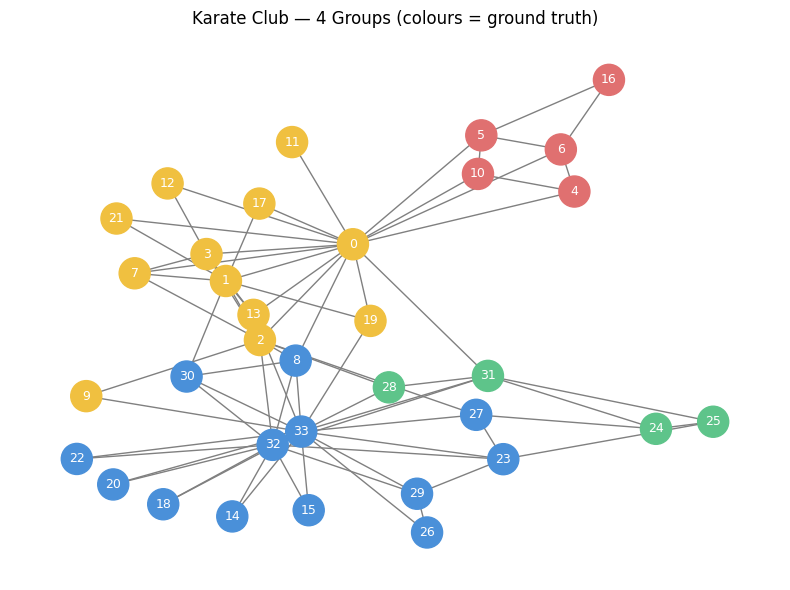

In [3]:
import torch_geometric

# Convert PyG graph -> NetworkX so we can draw it
G           = torch_geometric.utils.to_networkx(data, to_undirected=True)
true_labels = data.y.numpy()

# 4 colours for 4 groups
COLOURS      = ['#4A90D9', '#F0C040', '#5EC48A', '#E07070']
node_colours = [COLOURS[label] for label in true_labels]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)      # fixed seed so layout doesn't change
nx.draw_networkx(
    G, pos=pos,
    node_color=node_colours,
    node_size=500,
    font_color='white',
    edge_color='gray',
    font_size=9
)
plt.title('Karate Club — 4 Groups (colours = ground truth)')
plt.axis('off')
plt.tight_layout()
plt.savefig('karate_graph.png', dpi=120)
plt.show()

---
## Cell 4 — Message Passing by Hand (No PyG)

Before using any library, let's write the **AGGREGATE + UPDATE** steps ourselves
using only plain Python, so the idea is 100% clear.

**The rule (from Hamilton Ch5):**
```
For each node u:
    Step 1 (AGGREGATE): collect the feature vectors of all neighbours, then SUM them
    Step 2 (UPDATE):    new_feature = ReLU( W_self * own_feature + W_neigh * sum )
```

We use a tiny 4-node ring graph: **0 — 1 — 2 — 3 — 0**

In [4]:
torch.manual_seed(0)

# Tiny graph: 4 nodes, each with a 2-number feature vector
node_features = torch.tensor([
    [1.0, 0.0],   # node 0
    [0.0, 1.0],   # node 1
    [1.0, 1.0],   # node 2
    [0.5, 0.5],   # node 3
])

# Who is connected to whom (ring: 0-1, 1-2, 2-3, 3-0)
neighbours = {
    0: [1, 3],
    1: [0, 2],
    2: [1, 3],
    3: [2, 0],
}

# Small weight matrices  (in real training, these get learned by backprop)
W_self  = torch.tensor([[0.5, 0.0], [0.0, 0.5]])   # 2x2
W_neigh = torch.tensor([[0.3, 0.0], [0.0, 0.3]])   # 2x2

# ONE layer of message passing
new_features = torch.zeros_like(node_features)

for node in range(4):                               # loop over every node

    # STEP 1 — AGGREGATE: sum the feature vectors of all neighbours
    neighbour_sum = torch.zeros(2)                  # start from zero
    for nb in neighbours[node]:
        neighbour_sum += node_features[nb]          # add each neighbour's vector

    # STEP 2 — UPDATE: combine self info + neighbourhood message
    self_part  = W_self  @ node_features[node]     # what this node knows itself
    neigh_part = W_neigh @ neighbour_sum            # what the neighbours say
    combined   = self_part + neigh_part             # add both
    new_features[node] = torch.relu(combined)       # ReLU activation (= sigma)

print('BEFORE message passing (original features):')
for i, f in enumerate(node_features):
    print(f'   Node {i}: {f.tolist()}')

print('\nAFTER 1 round of message passing (new features):')
for i, f in enumerate(new_features):
    print(f'   Node {i}: {[round(x,3) for x in f.tolist()]}')

print()
print('Node 0 now has information from Node 1 and Node 3 (its neighbours).')
print('After 2 rounds, Node 0 would also know about Node 2 (2-hop neighbour).')

BEFORE message passing (original features):
   Node 0: [1.0, 0.0]
   Node 1: [0.0, 1.0]
   Node 2: [1.0, 1.0]
   Node 3: [0.5, 0.5]

AFTER 1 round of message passing (new features):
   Node 0: [0.65, 0.45]
   Node 1: [0.6, 0.8]
   Node 2: [0.65, 0.95]
   Node 3: [0.85, 0.55]

Node 0 now has information from Node 1 and Node 3 (its neighbours).
After 2 rounds, Node 0 would also know about Node 2 (2-hop neighbour).


---
## Cell 5 — Build and Train a GCN

**GCN = Graph Convolutional Network** (Kipf & Welling, 2017)

Same message passing as above, but with one extra trick:
it **divides each neighbour's contribution by sqrt(degree_u * degree_v)**
so hub-nodes with many connections don't overwhelm smaller nodes.

```
GCNConv does:  h_u = ReLU( W * sum_v( h_v / sqrt(deg_u * deg_v) ) )
```

Our network has **2 layers**:
- Layer 1: each node learns from its **direct neighbours** (1-hop)
- Layer 2: each node learns from **neighbours' neighbours** (2-hop)

GCN  --  Train accuracy: 100%   Test accuracy: 100%


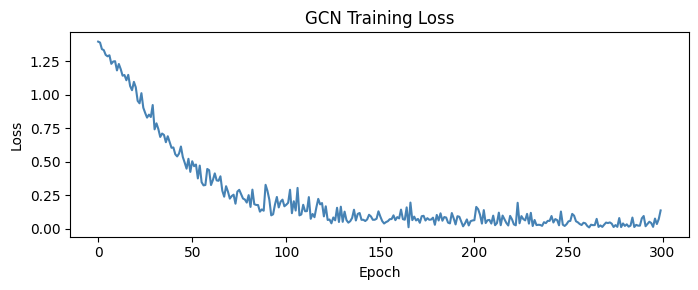

In [5]:
# Define the GCN model
class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: 34-dim input -> 16-dim hidden embedding
        self.layer1 = GCNConv(in_channels=34, out_channels=16)
        # Layer 2: 16-dim -> 4-dim output  (one score per class)
        self.layer2 = GCNConv(in_channels=16, out_channels=4)

    def forward(self, x, edge_index):
        x = self.layer1(x, edge_index)             # aggregate 1-hop neighbours
        x = F.relu(x)                               # non-linearity
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.layer2(x, edge_index)             # aggregate 2-hop neighbours
        return x                                    # shape [34, 4]

    def get_hidden(self, x, edge_index):
        """Return the 16-dim embedding (before final layer) for visualisation."""
        return F.relu(self.layer1(x, edge_index))


# Make train / test split  (70% train, 30% test)
torch.manual_seed(42)
n          = data.num_nodes                        # 34
perm       = torch.randperm(n)
train_mask = torch.zeros(n, dtype=torch.bool)
test_mask  = torch.zeros(n, dtype=torch.bool)
train_mask[perm[:24]] = True                       # 24 nodes for training
test_mask [perm[24:]] = True                       # 10 nodes for testing

# Train
model_gcn = GCN()
optimiser = torch.optim.Adam(model_gcn.parameters(), lr=0.01)
losses    = []

for epoch in range(300):
    model_gcn.train()
    optimiser.zero_grad()
    scores = model_gcn(data.x, data.edge_index)    # forward pass
    loss   = F.cross_entropy(scores[train_mask], data.y[train_mask])
    loss.backward()
    optimiser.step()
    losses.append(loss.item())

# Evaluate
model_gcn.eval()
with torch.no_grad():
    scores    = model_gcn(data.x, data.edge_index)
    predicted = scores.argmax(dim=1)

train_acc = (predicted[train_mask] == data.y[train_mask]).float().mean()
test_acc  = (predicted[test_mask]  == data.y[test_mask] ).float().mean()
print(f'GCN  --  Train accuracy: {train_acc:.0%}   Test accuracy: {test_acc:.0%}')

# Loss curve
plt.figure(figsize=(7, 3))
plt.plot(losses, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('GCN Training Loss')
plt.tight_layout()
plt.savefig('gcn_loss.png', dpi=120)
plt.show()

---
## Cell 6 — Build and Train a GAT

**GAT = Graph Attention Network** (Velickovic et al., 2018)

The only difference from GCN:
- **GCN** uses a *fixed* formula to weight each neighbour (degree-based).
- **GAT** *learns* how much to attend to each neighbour — irrelevant neighbours get low weight.

```
GCN:   h_u = ReLU( W * sum_v( fixed_weight(u,v) * h_v ) )
GAT:   h_u = ReLU( W * sum_v( learned_alpha(u,v) * h_v ) )
```

We also use **4 attention heads** (4 independent attention sets, results concatenated).

In [6]:
# Define the GAT model
class GAT(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: 4 heads x 8-dim each = 32-dim output
        self.layer1 = GATConv(in_channels=34, out_channels=8, heads=4, concat=True)
        # Layer 2: single head, 4 class scores
        self.layer2 = GATConv(in_channels=32, out_channels=4, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = self.layer1(x, edge_index)
        x = F.elu(x)                               # ELU is standard for GAT
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.layer2(x, edge_index)
        return x

    def get_hidden(self, x, edge_index):
        return F.elu(self.layer1(x, edge_index))


# Train
model_gat = GAT()
optimiser = torch.optim.Adam(model_gat.parameters(), lr=0.005)

for epoch in range(300):
    model_gat.train()
    optimiser.zero_grad()
    scores = model_gat(data.x, data.edge_index)
    loss   = F.cross_entropy(scores[train_mask], data.y[train_mask])
    loss.backward()
    optimiser.step()

# Evaluate
model_gat.eval()
with torch.no_grad():
    scores    = model_gat(data.x, data.edge_index)
    predicted = scores.argmax(dim=1)

train_acc = (predicted[train_mask] == data.y[train_mask]).float().mean()
test_acc  = (predicted[test_mask]  == data.y[test_mask] ).float().mean()
print(f'GAT  --  Train accuracy: {train_acc:.0%}   Test accuracy: {test_acc:.0%}')
print()
print('GCN uses fixed degree-based weights.  GAT learns different weights per neighbour.')
print('Both do the same AGGREGATE + UPDATE steps — they differ only in HOW they weight.')

GAT  --  Train accuracy: 100%   Test accuracy: 80%

GCN uses fixed degree-based weights.  GAT learns different weights per neighbour.
Both do the same AGGREGATE + UPDATE steps — they differ only in HOW they weight.


---
## Cell 7 — Over-Smoothing: Too Many Layers = Bad

From the notes:
> *If you stack too many GNN layers, every node keeps aggregating from its neighbours,*
> *who aggregate from their neighbours... eventually all embeddings become identical.*

We prove this: train the same GCN with 2, 4, 8, 16 layers and watch accuracy fall.

    2 layers  ->  test accuracy: 90%
    4 layers  ->  test accuracy: 90%
    8 layers  ->  test accuracy: 80%
   16 layers  ->  test accuracy: 80%


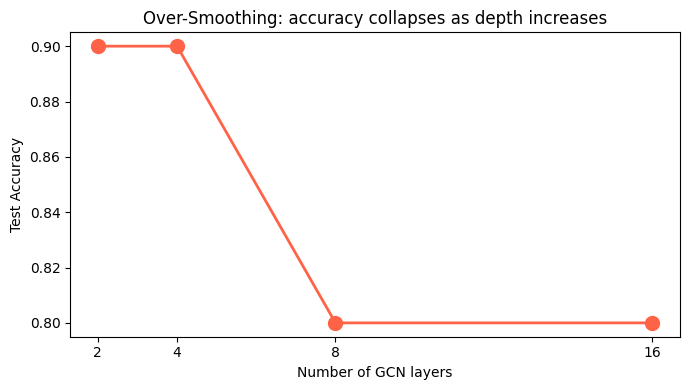


At 16 layers every node has seen the full graph so many times
all embeddings look the same -> cannot classify anymore.


In [7]:
# GCN with any number of layers
class DeepGCN(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(GCNConv(34, 16))         # first:  34 -> 16
        for _ in range(num_layers - 2):
            self.layers.append(GCNConv(16, 16))     # middle: 16 -> 16
        self.layers.append(GCNConv(16, 4))          # last:   16 -> 4

    def forward(self, x, edge_index):
        for i, layer in enumerate(self.layers):
            x = layer(x, edge_index)
            if i < len(self.layers) - 1:            # no ReLU on the very last layer
                x = F.relu(x)
        return x


# Train each depth and record test accuracy
depths    = [2, 4, 8, 16]
test_accs = []

for depth in depths:
    model = DeepGCN(num_layers=depth)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(300):
        model.train(); opt.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[train_mask], data.y[train_mask])
        loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(data.x, data.edge_index).argmax(dim=1)
    acc = (preds[test_mask] == data.y[test_mask]).float().mean().item()
    test_accs.append(acc)
    print(f'   {depth:>2} layers  ->  test accuracy: {acc:.0%}')

# Plot
plt.figure(figsize=(7, 4))
plt.plot(depths, test_accs, marker='o', color='tomato', linewidth=2, markersize=10)
plt.xlabel('Number of GCN layers')
plt.ylabel('Test Accuracy')
plt.title('Over-Smoothing: accuracy collapses as depth increases')
plt.xticks(depths)
plt.tight_layout()
plt.savefig('over_smoothing.png', dpi=120)
plt.show()
print()
print('At 16 layers every node has seen the full graph so many times')
print('all embeddings look the same -> cannot classify anymore.')

---
## Cell 8 — Fix: Jumping Knowledge (JK-Net)

From the notes:
> *Jumping Knowledge: harvest node representations from every single layer*
> *and combine them at the very end.*

```
z_u = concat( h_u_layer1 , h_u_layer2 , ... , h_u_layerK )
```

Layer 1's output = sharp, local info.
Layer 8's output = broad, global info.
We keep **all of them** instead of only the last one.

In [8]:
# JK-Net: save every layer's output, concatenate at the end
class JKNet(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(GCNConv(34, 16))         # first layer
        for _ in range(num_layers - 1):
            self.layers.append(GCNConv(16, 16))     # all other layers

        # Classifier input = 16 * num_layers  (one 16-dim vector from each layer)
        self.classifier = nn.Linear(16 * num_layers, 4)

    def forward(self, x, edge_index):
        all_outputs = []                            # collect every layer's output
        for layer in self.layers:
            x = F.relu(layer(x, edge_index))
            all_outputs.append(x)                  # <- save it

        combined = torch.cat(all_outputs, dim=1)   # stack side-by-side
        return self.classifier(combined)            # final class scores


NUM_LAYERS = 8

# Plain deep GCN
plain = DeepGCN(num_layers=NUM_LAYERS)
opt   = torch.optim.Adam(plain.parameters(), lr=0.01)
for epoch in range(300):
    plain.train(); opt.zero_grad()
    loss = F.cross_entropy(plain(data.x, data.edge_index)[train_mask], data.y[train_mask])
    loss.backward(); opt.step()
plain.eval()
with torch.no_grad():
    acc_plain = (plain(data.x, data.edge_index).argmax(1)[test_mask] == data.y[test_mask]).float().mean().item()

# JK-Net
jk    = JKNet(num_layers=NUM_LAYERS)
opt   = torch.optim.Adam(jk.parameters(), lr=0.01)
for epoch in range(300):
    jk.train(); opt.zero_grad()
    loss = F.cross_entropy(jk(data.x, data.edge_index)[train_mask], data.y[train_mask])
    loss.backward(); opt.step()
jk.eval()
with torch.no_grad():
    acc_jk = (jk(data.x, data.edge_index).argmax(1)[test_mask] == data.y[test_mask]).float().mean().item()

print(f'8-layer plain GCN  ->  {acc_plain:.0%}  (over-smoothed)')
print(f'8-layer JK-Net     ->  {acc_jk:.0%}  (fixed)')
print()
print('JK-Net recovers performance by using ALL layers, not just the last one.')

8-layer plain GCN  ->  80%  (over-smoothed)
8-layer JK-Net     ->  80%  (fixed)

JK-Net recovers performance by using ALL layers, not just the last one.


---
## Cell 9 — See What the GCN Learned (t-SNE)

After training, each node has a **16-dimensional embedding** — we cannot visualise 16D.

t-SNE shrinks them to **2D** so we can plot them. If the GCN has learned well,
nodes of the same group should form **separate clusters** in 2D
— even though the model never saw labels during this step.

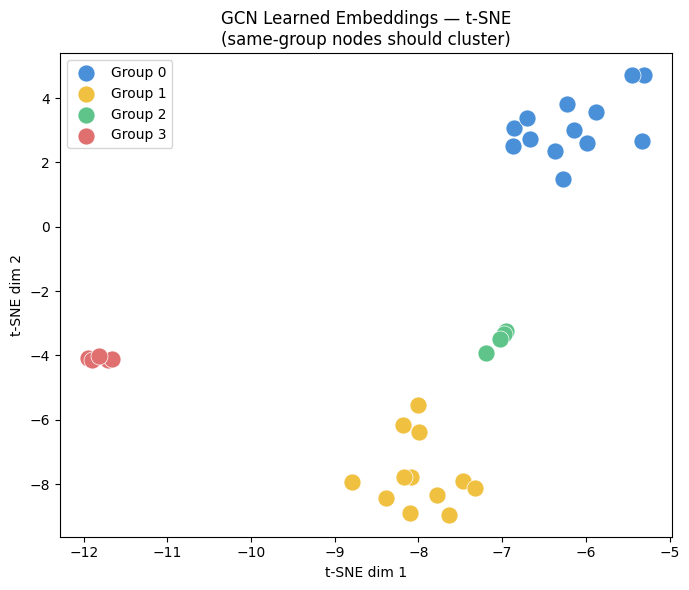

If the 4 colours form separate blobs -> the GCN learned meaningful embeddings.
This is the same idea as Word2Vec: similar things end up close in vector space.


In [9]:
# Extract 16-dim hidden embeddings from the trained GCN
model_gcn.eval()
with torch.no_grad():
    emb_16d = model_gcn.get_hidden(data.x, data.edge_index)   # [34, 16]

# Shrink to 2D with t-SNE
tsne   = TSNE(n_components=2, perplexity=10, max_iter=1000, random_state=42)
emb_2d = tsne.fit_transform(emb_16d.numpy())                   # [34, 2]

# Plot  (colour = true group label)
plt.figure(figsize=(7, 6))
for group in range(4):
    mask = data.y.numpy() == group
    plt.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=COLOURS[group], s=150, label=f'Group {group}',
        edgecolors='white', linewidths=0.5
    )
plt.legend()
plt.title('GCN Learned Embeddings — t-SNE\n(same-group nodes should cluster)')
plt.xlabel('t-SNE dim 1'); plt.ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('tsne_gcn.png', dpi=120)
plt.show()
print('If the 4 colours form separate blobs -> the GCN learned meaningful embeddings.')
print('This is the same idea as Word2Vec: similar things end up close in vector space.')

---
## Summary

| What we did | Concept it shows |
|---|---|
| Cell 4 — hand-coded message passing | AGGREGATE (sum) + UPDATE (W_self + W_neigh + ReLU) |
| Cell 5 — GCN | Degree-based normalisation; 2-hop receptive field |
| Cell 6 — GAT | Learned alpha_u_v per neighbour (attention) |
| Cell 7 — depth experiment | Over-smoothing: 16-layer GCN loses accuracy |
| Cell 8 — JK-Net | Use ALL layers -> no info lost |
| Cell 9 — t-SNE | Learned embeddings visually separate by community |

**Key difference between models:**
```
BasicGNN -> sum neighbours  (no normalisation)
GCN      -> sum neighbours / sqrt(deg_u * deg_v)   <- fixed scaling
GAT      -> alpha_u_v * h_v for each v             <- learned scaling
```
All three do AGGREGATE then UPDATE.
They only differ in **how** they weight the neighbours.